In [3]:
from google.colab import files
uploaded = files.upload()


Saving superstore_final_dataset (1).csv to superstore_final_dataset (1) (1).csv


In [4]:
import os
print(os.listdir())

['.config', 'superstore_final_dataset (1).csv', 'superstore_final_dataset (1) (1).csv', 'sample_data']


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('superstore_final_dataset (1).csv', encoding='latin1')


df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], dayfirst=True)


df['Month'] = df['Order_Date'].dt.month
df['Year'] = df['Order_Date'].dt.year
df['Month_Name'] = df['Order_Date'].dt.strftime('%b')

print(" Data loaded successfully!")
print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

 Data loaded successfully!
Total rows: 9800
Columns: ['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Sales', 'Month', 'Year', 'Month_Name']


In [11]:
total_revenue = df['Sales'].sum()
avg_order_value = df.groupby('Order_ID')['Sales'].sum().mean()
total_orders = df['Order_ID'].nunique()
total_customers = df['Customer_ID'].nunique()

print("========== KEY KPIs ==========")
print(f" Total Revenue:      ${total_revenue:,.2f}")
print(f" Total Orders:       {total_orders}")
print(f" Total Customers:    {total_customers}")
print(f" Avg Order Value:    ${avg_order_value:,.2f}")

========== KEY KPIs ==========
 Total Revenue:      $2,261,536.78
 Total Orders:       4922
 Total Customers:    793
 Avg Order Value:    $459.48


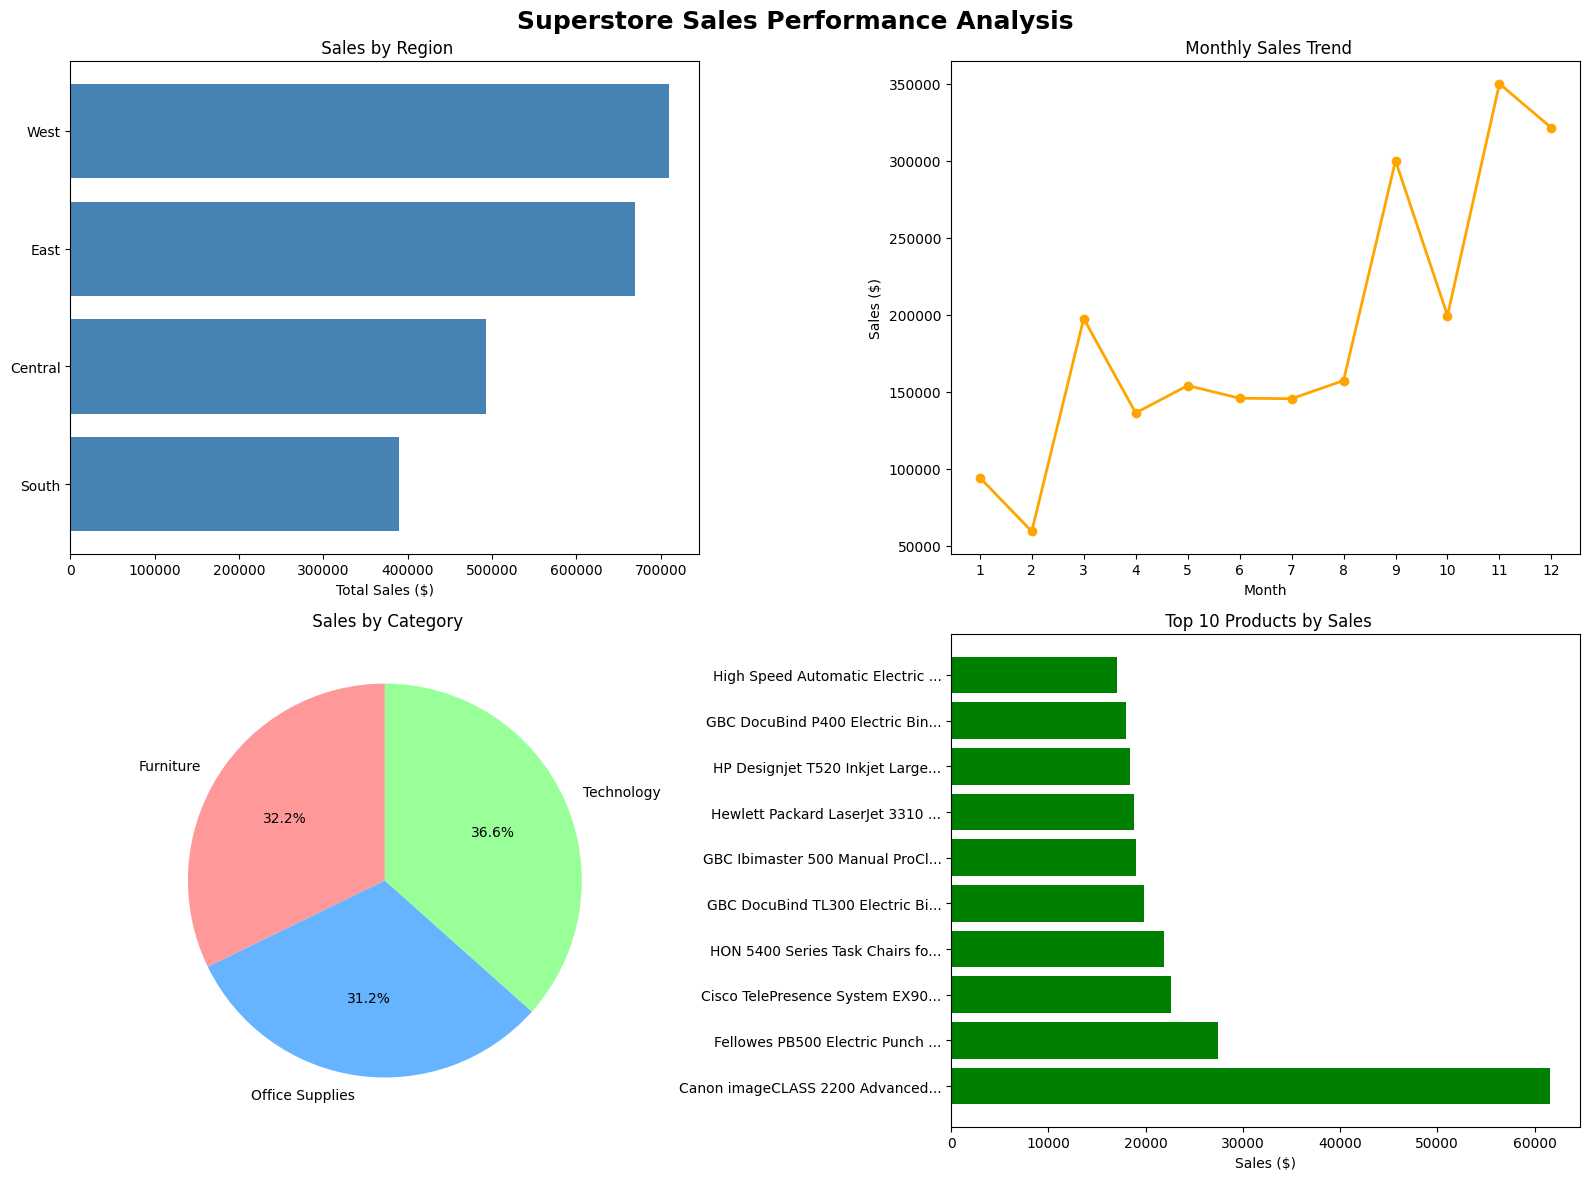

 Charts saved!


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Superstore Sales Performance Analysis', fontsize=18, fontweight='bold')

# Chart 1: Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values()
axes[0,0].barh(region_sales.index, region_sales.values, color='steelblue')
axes[0,0].set_title(' Sales by Region')
axes[0,0].set_xlabel('Total Sales ($)')

# Chart 2: Monthly Sales Trend
monthly = df.groupby('Month')['Sales'].sum()
axes[0,1].plot(monthly.index, monthly.values, marker='o', color='orange', linewidth=2)
axes[0,1].set_title(' Monthly Sales Trend')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Sales ($)')
axes[0,1].set_xticks(range(1,13))

# Chart 3: Sales by Category
cat_sales = df.groupby('Category')['Sales'].sum()
axes[1,0].pie(cat_sales, labels=cat_sales.index, autopct='%1.1f%%', startangle=90,
              colors=['#ff9999','#66b3ff','#99ff99'])
axes[1,0].set_title(' Sales by Category')

# Chart 4: Top 10 Products
top_products = df.groupby('Product_Name')['Sales'].sum().nlargest(10)
short_names = [name[:30]+'...' if len(name)>30 else name for name in top_products.index]
axes[1,1].barh(short_names, top_products.values, color='green')
axes[1,1].set_title(' Top 10 Products by Sales')
axes[1,1].set_xlabel('Sales ($)')

plt.tight_layout()
plt.savefig('sales_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Charts saved!")

In [9]:
print(" TOP 5 BEST SELLING PRODUCTS:")
print(df.groupby('Product_Name')['Sales'].sum().nlargest(5).to_string())

print("\n TOP 5 WORST SELLING PRODUCTS:")
print(df.groupby('Product_Name')['Sales'].sum().nsmallest(5).to_string())

print("\n SALES BY REGION:")
print(df.groupby('Region')['Sales'].sum().sort_values(ascending=False).to_string())

print("\n SALES BY CATEGORY:")
print(df.groupby('Category')['Sales'].sum().sort_values(ascending=False).to_string())

print("\n SALES BY CUSTOMER SEGMENT:")
print(df.groupby('Segment')['Sales'].sum().sort_values(ascending=False).to_string())

 TOP 5 BEST SELLING PRODUCTS:
Product_Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479

 TOP 5 WORST SELLING PRODUCTS:
Product_Name
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac    1.624
Avery 5                                                             5.760
Xerox 20                                                            6.480
Grip Seal Envelopes                                                 7.072
Acme Serrated Blade Letter Opener                                   7.632

 SALES BY REGION:
Region
West       710219.6845
East       669518.7260
Central    492646.9132
So

1.Focus on West/East region — highest revenue, expand marketing there
2.Promote Technology category — consistently top performer
3.Run seasonal campaigns in low months (check your chart for dips)
4.Investigate low-selling products and consider discontinuing them
5.Target Corporate & Consumer segments with personalized offers